In [37]:
import numpy as np
import pickle
import networkx as nx
import pandas as pd

import scipy as sp
import scipy.stats as stats
from scipy.optimize import curve_fit

import matplotlib.pyplot as plt
import matplotlib

from _helper_functions import cb
from _helper_functions import zipdf


import _helper_grammar_functions as jsgo

In [6]:
fn='01-Calculate-Enhancer-Activity-Levels/02-generated-tables//endf.rescaledPctl_45_85.wtcollapsed.sumRnaDivSumDna-repSum.pd.df.pickle'
allDF=pd.read_pickle(fn).set_index('wt-enhancer-seq')
allDF.head()

,enhancer-id,enhancer-sites,wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled,abl-enhancer-seq,abl-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled,act-change-bin,enhancer-dependent-gata-ets
wt-enhancer-seq,,,,,,,
CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATTGCTCAATATCTAAGATAGGA,Otx-a WT,L1-G1R-L2-E1F-L3-E2F-L4-G2R-L5-G3F-L6,1.197798,CATCTGAAGCTCGTTATTTCTAACGCAAGTTTTCGAAAAGCAAATT...,0.848065,"(1, 0)",0
CATCTGAAGCTCGAGATAACTAACGGAAGTTTTCGAAAAGGAAATTGCTCAATATCTAAGATAGGA,ORL351560,L1-G1F-L2-E1F-L3-E2F-L4-G2R-L5-G3F-L6,0.856235,CATCTGAAGCTCGAAATAACTAACGCAAGTTTTCGAAAAGCAAATT...,-1.100699,"(0, -1)",0
CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATTGCTCAGATATTAAGATAGGA,ORL108031,L1-G1R-L2-E1F-L3-E2F-L4-G2F-L5-G3F-L6,0.777169,CATCTGAAGCTCGTTATTTCTAACGCAAGTTTTCGAAAAGCAAATT...,0.706492,"(0, 0)",0
CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATTGCTCAATATCTCCTATCTTA,ORL414244,L1-G1R-L2-E1F-L3-E2F-L4-G2R-L5-G3R-L6,NaN,CATCTGAAGCTCGTTATTTCTAACGCAAGTTTTCGAAAAGCAAATT...,-1.486866,"(0, -1)",0
CATCTGAAGCTCGTTATCTCTAACTTCCGTTTTCGAAAAGGAAATTGCTCAATATCTAAGATAGGA,ORL280162,L1-G1R-L2-E1R-L3-E2F-L4-G2R-L5-G3F-L6,0.518839,CATCTGAAGCTCGTTATTTCTAACTTGCGTTTTCGAAAAGCAAATT...,-1.322202,"(0, -1)",0


In [7]:
## set hypergenometic null distribution

## frist remove all variants not dependent on gata and ets

# what are all active variants?
activityCol='wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled'
confidentPos=1
confidentNeg=0

active_seqs_all_gataets       = set(allDF.loc[allDF[activityCol]>=confidentPos,       :].index)
active_seqs_dependent_gataets = set(allDF.loc[allDF['enhancer-dependent-gata-ets']==1,:].index)

# what active variants not dependent on gata and ets
active_seqs_independent_gataets = active_seqs_all_gataets - active_seqs_dependent_gataets

# remove active variants not dependent on gata and ets
desired_seqs = set(allDF.index) - active_seqs_independent_gataets

# subset
allDF=allDF.loc[list(desired_seqs),:]
len(allDF)

431974

In [8]:
M      = len(allDF)                             # total number of objects            (ie total number enhancers)
n_func = sum(allDF[activityCol]>confidentPos)   # total number of type i objects     (ie total number of func ens)
n_nfun = sum(allDF[activityCol]<confidentNeg)   # total number of type i objects     (ie total number of nonfunc ens)

M,n_func,n_nfun

(431974, 52139, 143799)

In [9]:
#!!!!!! Jump back in here
mDF_fn='F05-Syntax-Features/5-stats-sig-motifs-possible-realData_filtMotifs=ord_ori_spc_minenrichFUNC=0.1_minN=50.pandas.df.pickle'
mDF=pd.read_pickle(mDF_fn)

In [10]:
mDF.head()

,phrase,phrase-type,phrase-length,phrase-is-spacing,real-data,hyp-func-p,func-enrich,func-odds-ratio,hyp-func-p-bonf
phrase-key,,,,,,,,,
ord_ori_spc=g_21_e_24_E,"(g, 21, e, 24, E)",parse_ord_ori_spc,3,True,"(63, 34, 7)",1.042766e-32,5.018826,11.206427,3.246130e-29
ord_ori_spc=g_13_e_24_E,"(g, 13, e, 24, E)",parse_ord_ori_spc,3,True,"(108, 73, 21)",1.030567e-46,4.429628,8.385350,3.208155e-43
ord_ori_spc=g_36_g_9_E,"(g, 36, g, 9, E)",parse_ord_ori_spc,3,True,"(162, 108, 42)",2.617632e-66,4.301851,7.889255,8.148688e-63
ord_ori_spc=g_15_E_22_E,"(g, 15, E, 22, E)",parse_ord_ori_spc,3,True,"(107, 85, 25)",6.657682e-42,4.085253,7.098879,2.072536e-38
ord_ori_spc=e_24_E_8_G,"(e, 24, E, 8, G)",parse_ord_ori_spc,3,True,"(105, 80, 29)",6.524524e-41,4.065093,7.029848,2.031084e-37


In [11]:
jsgo.motif_revcomp_with_phrasetype('ord_ori_spc=g_21_e_24_E')

'ord_ori_spc=e_24_E_21_G'

In [12]:
allSigMotifs=set()

for mi in mDF.index:
    allSigMotifs.add(mi)
    allSigMotifs.add(jsgo.motif_revcomp_with_phrasetype(mi))

In [18]:
with open('F05-Syntax-Features/Length2Phrase2ActList.pydict.pickle','rb') as f:
    Length2Phrase2ActList=pickle.load(f)

In [19]:

# Without the parse_
with open('F05-Syntax-Features//MotifGraph.without_parse_.pydict.pickle','rb') as f:
    MotifGraph=pickle.load(f)

In [20]:
list(MotifGraph.keys())[:3]

['ord_aff=G1_E1', 'ord_aff=G1_E2', 'ord_aff=G2_E1']

In [21]:
list(MotifGraph['ord_aff=G1_E1'])[:3]

['-aff', 'ori', 'spc']

# Show example of fitting model which you can use to fill in gaps

In [22]:
fnrealAll='F05-Syntax-Features/2-all-phrases-possible-withRealData-50k.pd.df.pickle'

dfAll=pd.read_pickle(fnrealAll)
dfAll['phrase-type']=dfAll['phrase-type'].apply(lambda s: s.replace("parse_",''))
dfAll['phrase-key']=dfAll['phrase'].apply(lambda s: '_'.join([str(si) for si in s]))

dfAll['phrase-key-unique']=dfAll.apply(lambda row: row['phrase-type']+'='+row['phrase-key'],axis=1)

dfAll=dfAll.set_index('phrase-key-unique')
dfAll.head()


,phrase,phrase-type,phrase-length,phrase-is-spacing,real-data,phrase-key
phrase-key-unique,,,,,,
ord_ori_spc=E_24_E,"(E, 24, E)",ord_ori_spc,2,True,"(297, 1183, 669)",E_24_E
ord_ori_spc=E_56_g,"(E, 56, g)",ord_ori_spc,2,True,"(642, 2224, 1402)",E_56_g
ord_ori_spc=g_33_G,"(g, 33, G)",ord_ori_spc,2,True,"(356, 1601, 921)",g_33_G
ord_ori_spc=G_24_G,"(G, 24, G)",ord_ori_spc,2,True,"(776, 4788, 3197)",G_24_G
ord_ori_spc=g_22_G,"(g, 22, G)",ord_ori_spc,2,True,"(2170, 8041, 4725)",g_22_G


In [23]:
dfAll.head()

,phrase,phrase-type,phrase-length,phrase-is-spacing,real-data,phrase-key
phrase-key-unique,,,,,,
ord_ori_spc=E_24_E,"(E, 24, E)",ord_ori_spc,2,True,"(297, 1183, 669)",E_24_E
ord_ori_spc=E_56_g,"(E, 56, g)",ord_ori_spc,2,True,"(642, 2224, 1402)",E_56_g
ord_ori_spc=g_33_G,"(g, 33, G)",ord_ori_spc,2,True,"(356, 1601, 921)",g_33_G
ord_ori_spc=G_24_G,"(G, 24, G)",ord_ori_spc,2,True,"(776, 4788, 3197)",G_24_G
ord_ori_spc=g_22_G,"(g, 22, G)",ord_ori_spc,2,True,"(2170, 8041, 4725)",g_22_G


In [24]:
strengthCol='func-odds-ratio'

# define function for getting missing spacing

In [25]:
mDF.head(1)

,phrase,phrase-type,phrase-length,phrase-is-spacing,real-data,hyp-func-p,func-enrich,func-odds-ratio,hyp-func-p-bonf
phrase-key,,,,,,,,,
ord_ori_spc=g_21_e_24_E,"(g, 21, e, 24, E)",parse_ord_ori_spc,3,True,"(63, 34, 7)",1.042766e-32,5.018826,11.206427,3.246130e-29


In [26]:
cols=[
    'phrase-key',
    'phrase-length',
    'func-odds-ratio',
    'real-data',
    'hyp-func-p-bonf'
]
spcDF=mDF.reset_index().loc[:,cols]
spcDF['num-total-seqs']=spcDF['real-data'].apply(lambda tup: sum(tup))
spcDF['num-active-ens']=spcDF['real-data'].apply(lambda tup: tup[0])
spcDF['obs-or-imputed']='obs'
spcDF.head()

,phrase-key,phrase-length,func-odds-ratio,real-data,hyp-func-p-bonf,num-total-seqs,num-active-ens,obs-or-imputed
0,ord_ori_spc=g_21_e_24_E,3,11.206427,"(63, 34, 7)",3.246130e-29,104,63,obs
1,ord_ori_spc=g_13_e_24_E,3,8.385350,"(108, 73, 21)",3.208155e-43,202,108,obs
2,ord_ori_spc=g_36_g_9_E,3,7.889255,"(162, 108, 42)",8.148688e-63,312,162,obs
3,ord_ori_spc=g_15_E_22_E,3,7.098879,"(107, 85, 25)",2.072536e-38,217,107,obs
4,ord_ori_spc=e_24_E_8_G,3,7.029848,"(105, 80, 29)",2.031084e-37,214,105,obs


In [30]:
def get_imputed_spacings(pdSeries):
    # linear interpolation
    x2height={xi:hi for xi,hi in zip(pdSeries.index,pdSeries)}
    
    rangeX=range(min(pdSeries.index),max(pdSeries.index)+1)
    heightsPlottedForSeries=[x2height[xi] if xi in x2height else np.NaN for xi in rangeX ]

    
    spcDF=pd.Series(heightsPlottedForSeries,index=rangeX)
    imputeDF=spcDF.interpolate()
        
    spcObserved=set(pdSeries.index)
    
    spcImputed=set(rangeX)-spcObserved
    
    return imputeDF,imputeDF[list(spcImputed)],imputeDF[list(spcObserved)]
    
    
# ex=pd.Series([50,60,70,90],index=[10,11,12,14])
# print(ex)
# get_imputed_spacings(ex)

In [31]:


def effect_curve(x,a,b,c,d):
    return c * np.sqrt(a*x+b) + d


In [32]:
numInertTotal=sum(allDF['wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled']<0)
numInertTotal

143799

# Fig S13: Periodicity and syntax feature imputation


E_11_e
[8219, 8816] N = 8517.5
% s  =  0.128
% p  =  27.281
act =  1088
background % =  52139 431974 0.12069939394500595
pval =  1
1088 2900.1945448429096 51051 140898.8054551571
OR = 1.035392039488614

E_19_e
[9578, 2102] N = 5840.0
% s  =  0.151
% p  =  33.925
act =  882
background % =  52139 431974 0.12069939394500595
pval =  9.513347930904876e-09
882 1717.862577274252 51257 142081.13742272576
OR = 1.423191716859255

E_9_e
[8816, 8786] N = 8801.0
% s  =  0.08
% p  =  17.696
act =  701
background % =  52139 431974 0.12069939394500595
pval =  1
701 3260.2851029505377 51438 140538.71489704947
OR = 0.5874546451818315

E_16_e
[1072, 8893] N = 4982.5
% s  =  0.101
% p  =  21.708
act =  503
background % =  52139 431974 0.12069939394500595
pval =  1
503 1814.0817013711176 51636 141984.91829862888
OR = 0.7624313862814868

E_12_e
[8219, 8816] N = 8517.5
% s  =  0.176
% p  =  37.229
act =  1501
background % =  52139 431974 0.12069939394500595
pval =  9.929243719989483e-48
1501 2530.8011567333

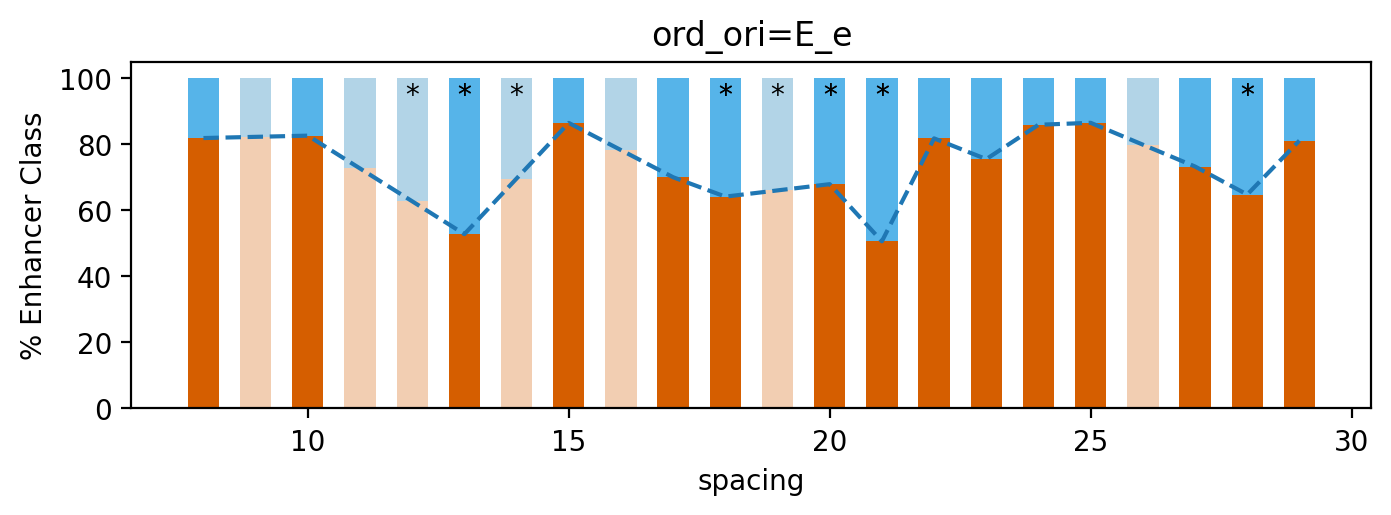

In [34]:
numTestsPerformed=5440

def get_missing_spacing_data_2mer(ordOriMotif,MotifGraph,spcMax,graphSpacingModel,graphEffectModel,savefigs,appendSpcDF=False):
    
    phraseLen=2
    
    # requires spcDF to already exist in memory with columns
    # 'phrase-key',
    # 'phrase-length',
    # 'func-odds-ratio',
    # 'obs-or-imputed'
    
    global spcDF
    global dfAll
    
    ordOriSpcObservedMotifs=MotifGraph[ordOriMotif]['spc']            
    
    ########################################################################
    # Get all phrases which exist
    ########################################################################
    
    if graphSpacingModel:
        fig,ax=plt.subplots(1,figsize=(8,2.25),dpi=200)
        
    # Check to see which spacicng are present in dicitonary
    phrasesToPlot=[]
    phrasesSeen=set()
    phrasesUnseen=set()
    for spci in range(7,spcMax):

        title='ord_ori_spc'
        t1,t2=ordOriMotif.split('=')[-1].split('_')
        phraseStr=f'{t1}_{spci}_{t2}'
        phraseKey=jsgo.get_phrase_key(phraseStr)
        phraseKeyRc=jsgo.get_phrase_key(jsgo.motif_revcomp_with_phrasetype(f'{title}={phraseStr}').split('=')[-1])
        # print(phraseKey)
        # print(phraseKeyRc)

        if phraseKey in Length2Phrase2ActList[phraseLen]:
            # print(phraseKey)
            phrasesToPlot.append((True,phraseStr,phraseKey,title,phraseLen,spci)) 
            phrasesSeen.add(phraseStr)
        
        elif phraseKeyRc in Length2Phrase2ActList[phraseLen]:
            # print(phraseKey)
            phrasesToPlot.append((True,phraseStr,phraseKeyRc,title,phraseLen,spci)) 
            phrasesSeen.add(phraseStr)

        else: 
            phrasesUnseen.add(phraseStr)

    heightsPlotted=[]
    percentSeqsWithMotifThatAreActive=[]
    spacingsPlotted=[]
    effectSizePlotted=[]
    effectSizeSpacingPlotted=[]
    spc2effect={}
    spc2sig={}
    for xi,(spacing,phrase,phraseKey,title,phraseLength,spci) in enumerate(phrasesToPlot):

        mi='ord_ori_spc='+phrase
        title=title.replace('parse_','')
        mi=f'{title}={phrase}'
        # print(mi)
        
        if mi not in dfAll.index:
            mi=jsgo.motif_revcomp_with_phrasetype(mi)

        FU,UN,NF=dfAll.at[mi,'real-data']
        
        if mi in mDF.index:
            pval=mDF.at[mi,'hyp-func-p-bonf']
            sig=pval<.05
            
        else:
            sig=0
        
        spc2sig[spci]=sig
        
        # print(FU,UN,NF)

        N=sum([FU,NF])

        # if plotOnXBySpacing:
        xi=spci

        bottom=0
        for bi,(height,color) in enumerate([(FU,cb['lightblue']),(NF,cb['red'])][::-1]):

            height=100*height/N
                
            if graphSpacingModel:
                if mi in allSigMotifs:
                    ax.text(xi,95,'*',ha='center',va='center')
                ax.bar(x=xi,height=height,bottom=bottom,color=color,width=.6)
                bottom+=height

        percentSeqsWithMotifThatAreActive.append(100*FU/(FU+UN+NF))
        heightsPlotted.append(100*FU/N)
        spacingsPlotted.append(spci)
        
        # if motif (and revcomp) not in DF
        if (mi not in mDF.index) and (jsgo.motif_revcomp_with_phrasetype(mi) not in mDF.index):
            pass
        
        else:
            effectSize=mDF.at[mi,strengthCol]
            effectSizePlotted.append(effectSize)
            effectSizeSpacingPlotted.append(spci)
            spc2effect[spci]=effectSize
        
    ########################################################################
    # Get predictor of % enrichment in func enhancers
    ########################################################################
     
    # Get all tbc observed
    spcObs=spacingsPlotted

    # get percent func
    spcObsSeries_forplot=pd.Series(heightsPlotted,index=spacingsPlotted)
    spcObsSeries_forstats=pd.Series(percentSeqsWithMotifThatAreActive,index=spacingsPlotted)
    # print(spcObsSeries)

    # get imputed values
    allSpcDF_forplot,imputeDF,obsDF=get_imputed_spacings(spcObsSeries_forplot)
    allSpcDF_forstats,_,_          =get_imputed_spacings(spcObsSeries_forstats)
    
    # print(allSpcDF_forplot)
        
    
    if graphSpacingModel:
        x=list(range(min(spacingsPlotted),max(spacingsPlotted)+1))
        ax.plot(x,[100-xi for xi in allSpcDF_forplot[x]],'--')    
        ax.set_ylabel('% Enhancer Class')
        ax.set_xlabel('spacing')
        ax.set_title(ordOriMotif)

    
    ########################################################################
    # Get predictor for effectsize
    ########################################################################

    spacingShared=[i for i in obsDF.index if i in spc2effect]
    x=[obsDF[i] for i in spacingShared]
    y=[spc2effect [spci] for spci in spacingShared ]
    
    # print(spacingShared)
    # print(spc2sig)
    sig2color={True:cb['blue'],False:cb['red']}
    colors=[sig2color[spc2sig[spci]] for spci in spacingShared ]


    # sort list by x
    x, y = zip(*sorted(zip(x, y)))
        
    # print(heightsPlotted)
    
    poly=1
    z=np.polyfit(x,y,poly)
    # effectEstimator=np.poly1d(z)
    
    
    minPercentFunctional=min(y)
    
    ########################################################################
    # Impute if spacing is func and effect size 
    ########################################################################
    
    # print(phrasesSeen)
    # print(phrasesUnseen)
    
    impPercent=[]
    impEffect =[]
    impLabel  =[]
    
    outcols=[\
     'phrase-key'     ,
     'phrase-length'  ,
     'func-odds-ratio',
     'hyp-func-p-bonf',
     'num-total-seqs' ,
     'num-active-ens' ,
     'obs-or-imputed' ,
     'real-data'
    ]
    
    c2v={c:[] for c in outcols}
    
    spc2averagespace={}
    for mi in phrasesUnseen:
        print()
        print(mi)
        
        t1,spc,t2=mi.split('_')
        spc=int(spc)
        
        sampleSizes=[]
        
        # get sample size for the nearest 2 motifs
        for direction in [+1,-1]:
            
            for bp in range(1,10):
                bp=bp*direction+spc
                seenMotif=f'ord_ori_spc={t1}_{bp}_{t2}'
                # print('trying',seenMotif)
                
                if seenMotif in dfAll.index:
                    # print('seen')
                    allCounts=dfAll.at[seenMotif,'real-data']
                    # classifiedCounts=[allCounts[0],allCounts[2]]
                    sampleSizes.append(sum(allCounts))        
                    break
                    
                elif jsgo.motif_revcomp_with_phrasetype(seenMotif) in dfAll.index:
                    # print('seen',seenMotif)
                    allCounts=dfAll.at[jsgo.motif_revcomp_with_phrasetype(seenMotif),'real-data']
                    # classifiedCounts=[allCounts[0],allCounts[2]]
                    sampleSizes.append(sum(allCounts))        
                    break
        
        
        avgSampleSizeOfNearMotifs=sum(sampleSizes)/len(sampleSizes)
        print(sampleSizes,'N =',avgSampleSizeOfNearMotifs)
        
        spc2averagespace[spc]=avgSampleSizeOfNearMotifs
        
        # predict percent enrichment
        if spc in allSpcDF_forplot:
            percent_forplot=allSpcDF_forplot[spc]
            
            if graphSpacingModel:
                ax.bar(x=spc,height=100-percent_forplot,bottom=0,color=cb['red'],alpha=.3,width=.6)
                ax.bar(x=spc,height=percent_forplot,bottom=100-percent_forplot,color=cb['blue'],alpha=.3,width=.6)

                
            # predict p value
            
            # Recall that...
            #    n = total number functional enhancers in lib dependent on gata/ets
            #    M = total number sequences in lib 
            #    N = number sequences with motif 
            #    k = number functional enhancers with motif

            percent_forstats=allSpcDF_forstats[spc]
            percent_forstats=percent_forstats/100 # 
            print('% s  = ',round(percent_forstats,3))
            print('% p  = ',round(percent_forplot,3))
            avgSampleSizeOfNearMotifs=int(spc2averagespace[spc])

            # if sample size too small, skip
            if avgSampleSizeOfNearMotifs<50: continue
                
            k_func=int(avgSampleSizeOfNearMotifs*percent_forstats)
            print('act = ',k_func)
            print('background % = ',n_func,M,n_func/M)
            
            
            pval=stats.hypergeom.sf(k=k_func, M=M, n=n_func, N=avgSampleSizeOfNearMotifs)

            pval=min(1,5440*pval) # number of tests performed for observed motifs
            print('pval = ',pval)
            
            enrichmentPercentMeasurement= (k_func/avgSampleSizeOfNearMotifs) / (n_func/M)

            # calculate odds ratio
            Fm = k_func # seqs with motif that are func
            num_Fm_and_Nm = Fm/(percent_forplot/100)
            Nm = num_Fm_and_Nm-Fm # seqs with motif that are inert
            Fn = n_func - Fm # seqs without motiif func
            Nn = numInertTotal - Nm # seqs without motiif inert

            Um=avgSampleSizeOfNearMotifs-Fm-Nm

            print(Fm,Nm,Fn,Nn)
            oddsratio = (Fm/Nm) / (Fn/Nn)
            print('OR =',oddsratio)
            # see if effect is sufficient to be significant accourding to the observed motifs
            if enrichmentPercentMeasurement>1.1 and pval<.05:

                # write this motif out
                c2v['phrase-key'].append(f'ord_ori_spc={mi}')
                c2v['phrase-length'].append(phraseLen)
                c2v['func-odds-ratio'].append(oddsratio)
                c2v['obs-or-imputed'].append('imp')
                c2v['hyp-func-p-bonf'].append(min(1,numTestsPerformed*pval))
                c2v['num-total-seqs' ].append(avgSampleSizeOfNearMotifs)
                c2v['num-active-ens' ].append(k_func)
                c2v['real-data' ].append((round(Fm),round(Um),round(Nm)))

                impPercent.append(100*percent_forstats)
                # impEffect.append(effect)
                impLabel.append(mi)

                ax.text(spc,95,'*',ha='center',va='center')
            
    if appendSpcDF:
        spcDF=pd.concat([spcDF,pd.DataFrame(c2v)])
    
    if graphSpacingModel:
        ax.set_xlabel("spacing")
        if savefigs:
            label=ordOriMotif.split('=')[-1]
            plt.savefig(f'000-manuscript-figs/06d_MOT_20230919_Syntax-Motif-Fill-Spacing-and-periodicity__spc-{label}.svg',bbox_inches='tight')
            plt.close(fig)
        else:
            plt.show()

            
get_missing_spacing_data_2mer('ord_ori=E_e',
                         MotifGraph,
                         spcMax=30,
                         graphSpacingModel=True,
                         graphEffectModel=True,
                         savefigs=False)

# Apply functions to all motifs

###############################################################
ANALYZING ord_ori=e_E

e_14_E
[8493, 8872] N = 8682.5
% s  =  0.109
% p  =  25.046
act =  950
background % =  52139 431974 0.12069939394500595
pval =  1
950 2843.0777331259237 51189 140955.92226687408
OR = 0.9201138189302039

e_26_E
[2201, 1987] N = 2094.0
% s  =  0.187
% p  =  40.546
act =  392
background % =  52139 431974 0.12069939394500595
pval =  3.682510691482204e-15
392 574.7939057257576 51747 143224.20609427424
OR = 1.8875790948689566

e_19_E
[9937, 2117] N = 6027.0
% s  =  0.114
% p  =  24.667
act =  686
background % =  52139 431974 0.12069939394500595
pval =  1
686 2095.011558282366 51453 141703.98844171764
OR = 0.9017975787297599

e_9_E
[8228, 8923] N = 8575.5
% s  =  0.133
% p  =  27.827
act =  1138
background % =  52139 431974 0.12069939394500595
pval =  1
1138 2951.61262865491 51001 140847.3873713451
OR = 1.0647631347002235

e_11_E
[8872, 8228] N = 8550.0
% s  =  0.161
% p  =  33.683
act =  1376
background % 

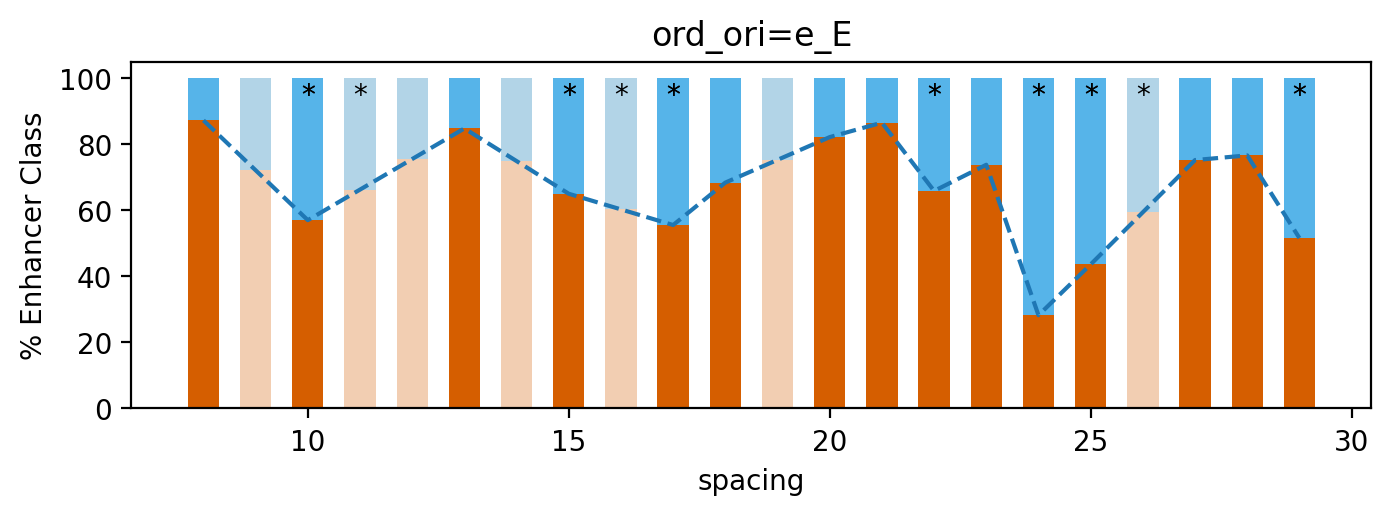

###############################################################
###############################################################
ANALYZING ord_ori=E_e

E_11_e
[8219, 8816] N = 8517.5
% s  =  0.128
% p  =  27.281
act =  1088
background % =  52139 431974 0.12069939394500595
pval =  1
1088 2900.1945448429096 51051 140898.8054551571
OR = 1.035392039488614

E_19_e
[9578, 2102] N = 5840.0
% s  =  0.151
% p  =  33.925
act =  882
background % =  52139 431974 0.12069939394500595
pval =  9.513347930904876e-09
882 1717.862577274252 51257 142081.13742272576
OR = 1.423191716859255

E_9_e
[8816, 8786] N = 8801.0
% s  =  0.08
% p  =  17.696
act =  701
background % =  52139 431974 0.12069939394500595
pval =  1
701 3260.2851029505377 51438 140538.71489704947
OR = 0.5874546451818315

E_16_e
[1072, 8893] N = 4982.5
% s  =  0.101
% p  =  21.708
act =  503
background % =  52139 431974 0.12069939394500595
pval =  1
503 1814.0817013711176 51636 141984.91829862888
OR = 0.7624313862814868

E_12_e
[8219, 8816] N

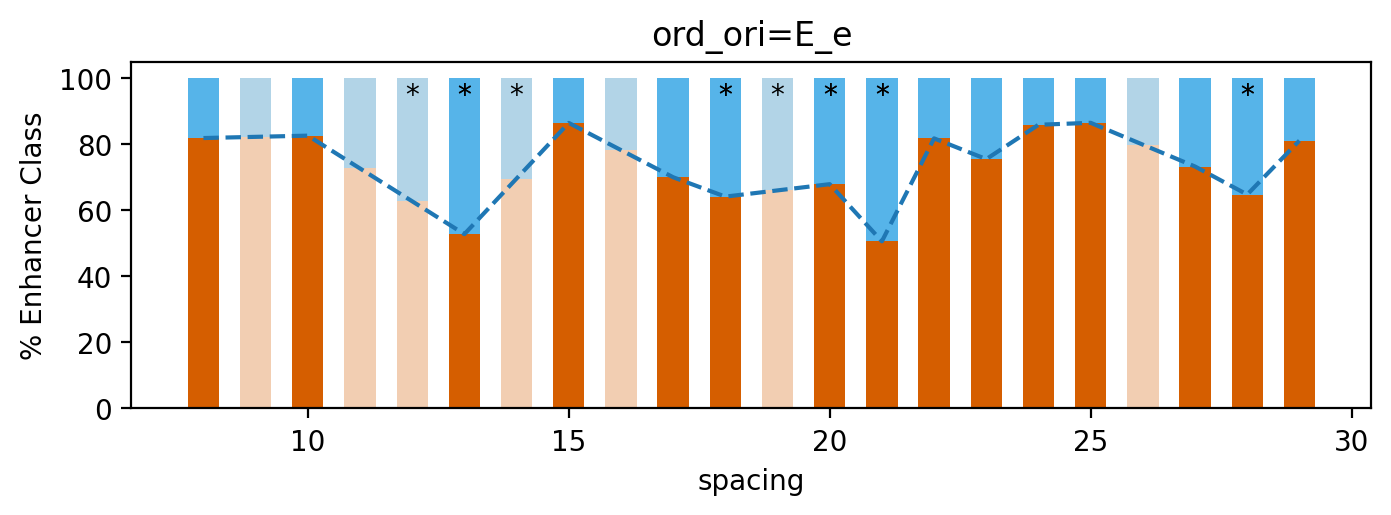

###############################################################
###############################################################
ANALYZING ord_ori=g_E

g_26_E
[21717, 8230] N = 14973.5
% s  =  0.147
% p  =  32.625
act =  2196
background % =  52139 431974 0.12069939394500595
pval =  1.097851556242315e-18
2196 4535.085800437165 49943 139263.91419956283
OR = 1.3502394698155034

g_16_E
[10523, 33035] N = 21779.0
% s  =  0.19
% p  =  40.476
act =  4140
background % =  52139 431974 0.12069939394500595
pval =  1.9945337319872494e-197
4140 6088.366222549099 47999 137710.6337774509
OR = 1.9508993354020785

g_11_E
[17553, 33600] N = 25576.5
% s  =  0.132
% p  =  28.64
act =  3381
background % =  52139 431974 0.12069939394500595
pval =  2.316922234222976e-05
3381 8424.149126184135 48758 135374.85087381586
OR = 1.1143233544560587


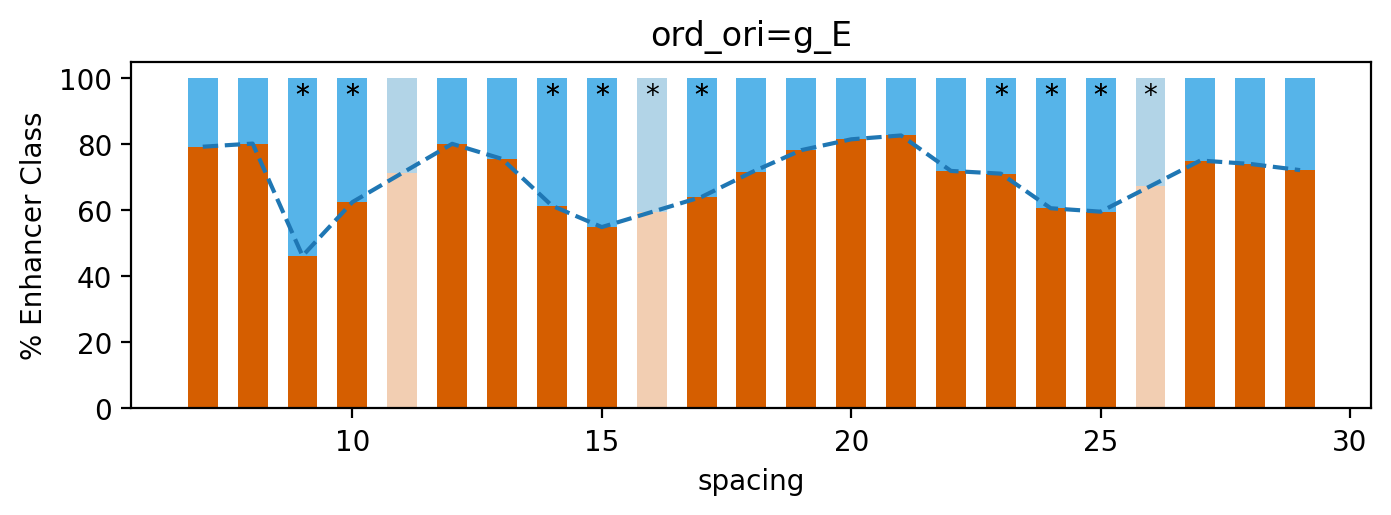

###############################################################
###############################################################
ANALYZING ord_ori=g_G

g_26_G
[15105, 2077] N = 8591.0
% s  =  0.168
% p  =  36.692
act =  1441
background % =  52139 431974 0.12069939394500595
pval =  1.2359443291785733e-34
1441 2486.301569530591 50698 141312.6984304694
OR = 1.6154761069598766

g_11_G
[17574, 8754] N = 13164.0
% s  =  0.098
% p  =  21.596
act =  1288
background % =  52139 431974 0.12069939394500595
pval =  1
1288 4676.038537304863 50851 139122.96146269515
OR = 0.7535934190358241

g_16_G
[7468, 8393] N = 7930.5
% s  =  0.156
% p  =  33.812
act =  1233
background % =  52139 431974 0.12069939394500595
pval =  5.06397633775182e-17
1233 2413.630069299306 50906 141385.3699307007
OR = 1.418821850643003


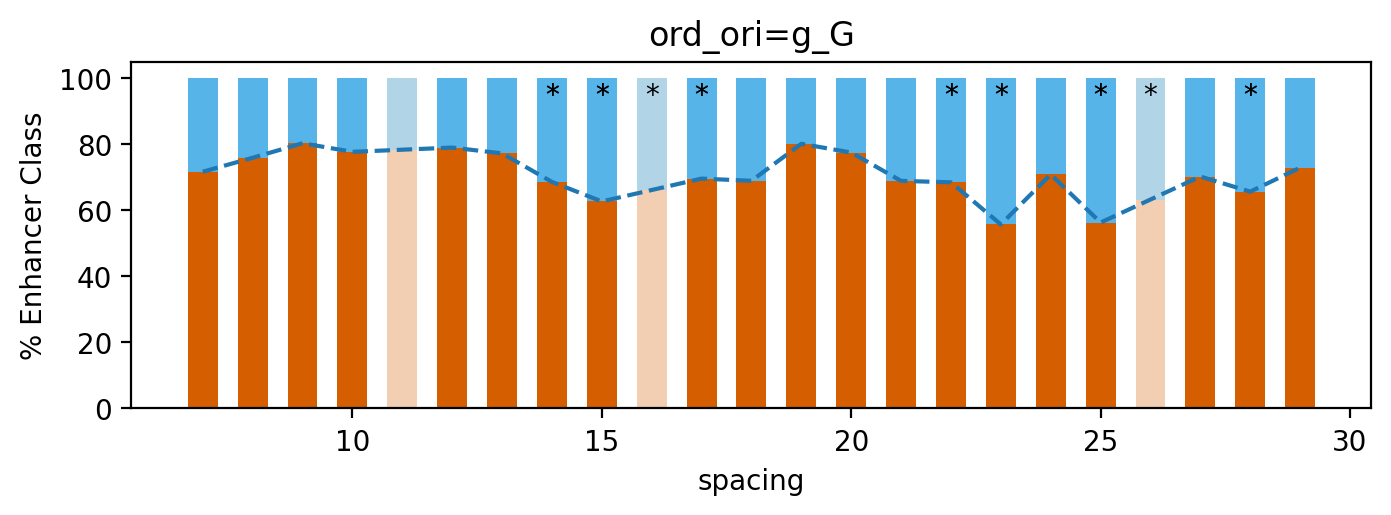

###############################################################
###############################################################
ANALYZING ord_ori=E_G

E_26_G
[21651, 8812] N = 15231.5
% s  =  0.1
% p  =  22.078
act =  1517
background % =  52139 431974 0.12069939394500595
pval =  1
1517 5354.159216717856 50622 138444.84078328215
OR = 0.7748752256175553

E_16_G
[10838, 35066] N = 22952.0
% s  =  0.102
% p  =  22.499
act =  2337
background % =  52139 431974 0.12069939394500595
pval =  1
2337 8049.944478171685 49802 135749.05552182833
OR = 0.7913267741515221

E_11_G
[17166, 34288] N = 25727.0
% s  =  0.138
% p  =  30.601
act =  3541
background % =  52139 431974 0.12069939394500595
pval =  7.396197087432351e-14
3541 8030.656542104722 48598 135768.34345789527
OR = 1.2318419702774506


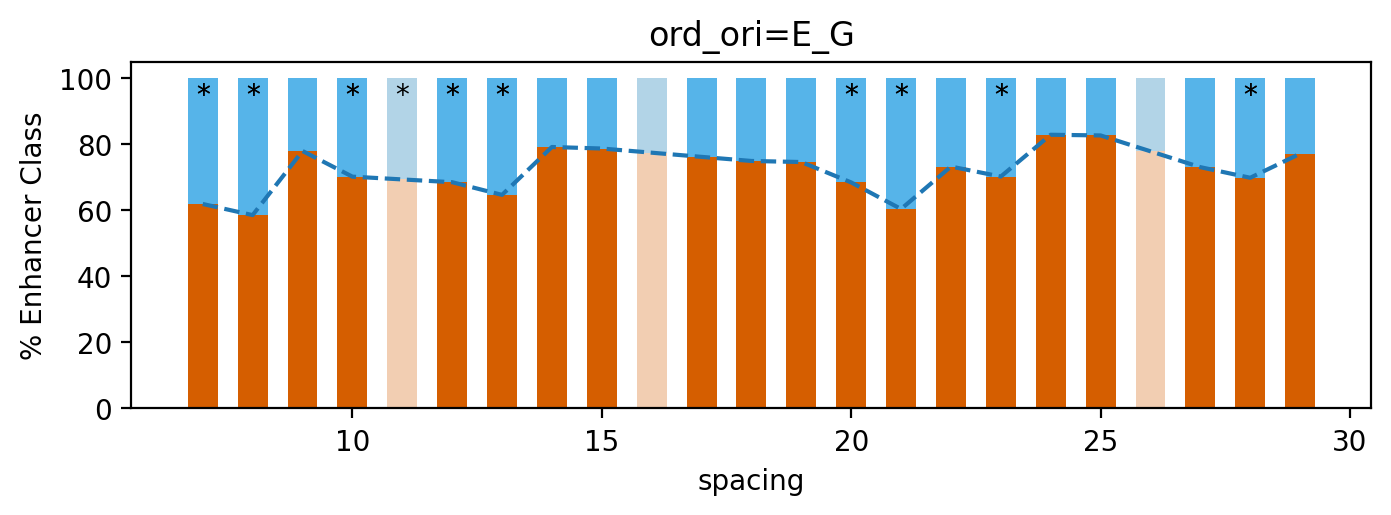

###############################################################
###############################################################
ANALYZING ord_ori=g_g

g_16_g
[8632, 34695] N = 21663.5
% s  =  0.115
% p  =  25.186
act =  2483
background % =  52139 431974 0.12069939394500595
pval =  1
2483 7375.807480992669 49656 136423.19251900734
OR = 0.9248762412352969

g_26_g
[17326, 10897] N = 14111.5
% s  =  0.113
% p  =  24.923
act =  1588
background % =  52139 431974 0.12069939394500595
pval =  1
1588 4783.55977552114 50551 139015.44022447887
OR = 0.9129197042806315

g_11_g
[17346, 35004] N = 26175.0
% s  =  0.104
% p  =  22.746
act =  2728
background % =  52139 431974 0.12069939394500595
pval =  1
2728 9265.477799712518 49411 134533.5222002875
OR = 0.8016474497408712


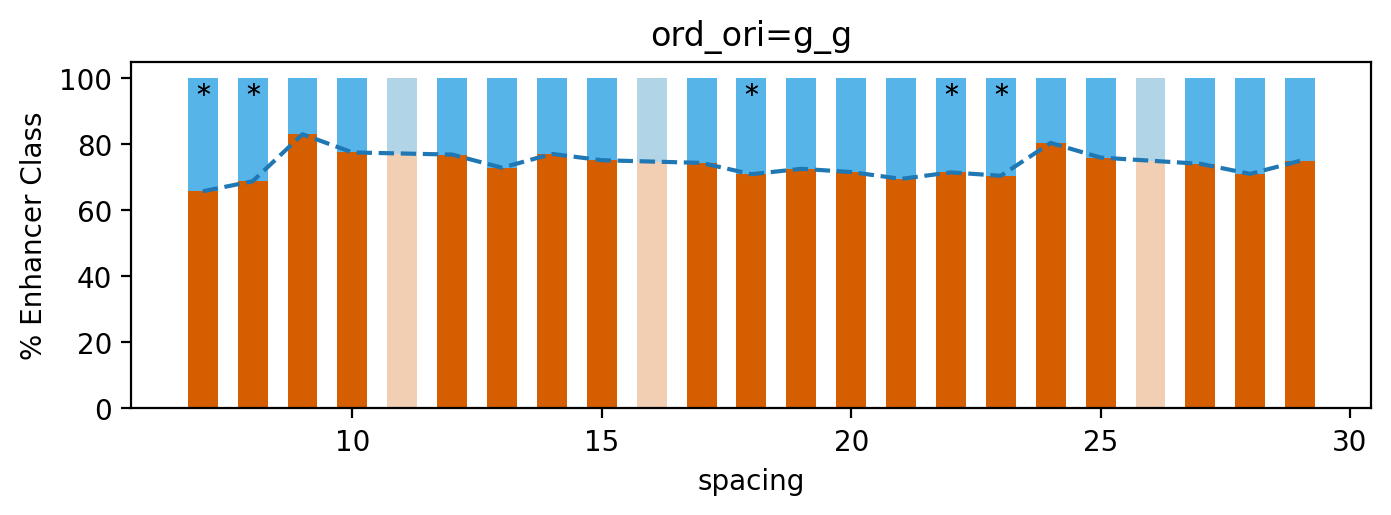

###############################################################
###############################################################
ANALYZING ord_ori=E_E

E_26_E
[4377, 4324] N = 4350.5
% s  =  0.101
% p  =  23.38
act =  438
background % =  52139 431974 0.12069939394500595
pval =  1
438 1435.369362415367 51701 142363.63063758463
OR = 0.8402539257518964

E_11_E
[17142, 17347] N = 17244.5
% s  =  0.122
% p  =  26.965
act =  2106
background % =  52139 431974 0.12069939394500595
pval =  1
2106 5704.066924006402 50033 138094.9330759936
OR = 1.019048735220019

E_14_E
[17569, 17142] N = 17355.5
% s  =  0.116
% p  =  25.997
act =  2013
background % =  52139 431974 0.12069939394500595
pval =  1
2013 5730.164677044041 50126 138068.83532295597
OR = 0.9676299080794944

E_16_E
[2140, 17569] N = 9854.5
% s  =  0.118
% p  =  25.957
act =  1161
background % =  52139 431974 0.12069939394500595
pval =  1
1161 3311.7811602004695 50978 140487.21883979952
OR = 0.9661056247180658

E_19_E
[19390, 4258] N = 11824

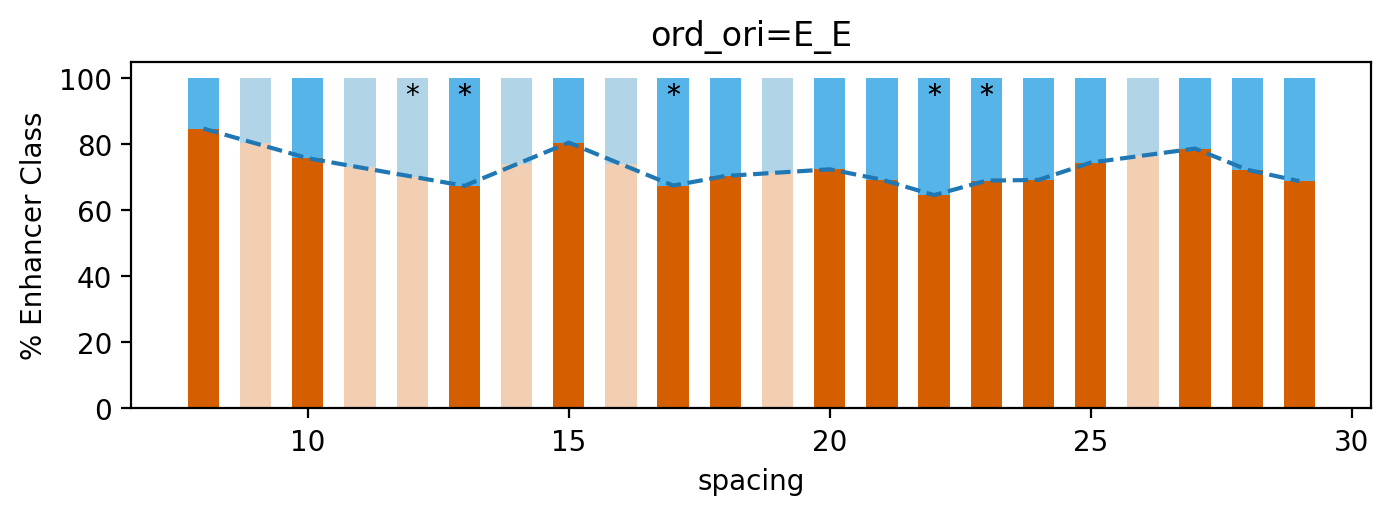

###############################################################
###############################################################
ANALYZING ord_ori=G_E

G_9_E
[50734, 52729] N = 51731.5
% s  =  0.126
% p  =  27.501
act =  6537
background % =  52139 431974 0.12069939394500595
pval =  0.07241983491475548
6537 17233.2386758172 45602 126565.7613241828
OR = 1.0527952762636061

G_12_E
[51948, 50734] N = 51341.0
% s  =  0.13
% p  =  28.515
act =  6661
background % =  52139 431974 0.12069939394500595
pval =  8.138135760785053e-08
6661 16698.501705871582 45478 127100.49829412843
OR = 1.1148278879111733

G_16_E
[4249, 51879] N = 28064.0
% s  =  0.137
% p  =  29.964
act =  3843
background % =  52139 431974 0.12069939394500595
pval =  5.1815320593547336e-14
3843 8982.17960660817 48296 134816.82039339183
OR = 1.194322370294721

G_11_E
[51948, 50734] N = 51341.0
% s  =  0.146
% p  =  31.841
act =  7511
background % =  52139 431974 0.12069939394500595
pval =  4.056151333018351e-73
7511 16078.2356772657

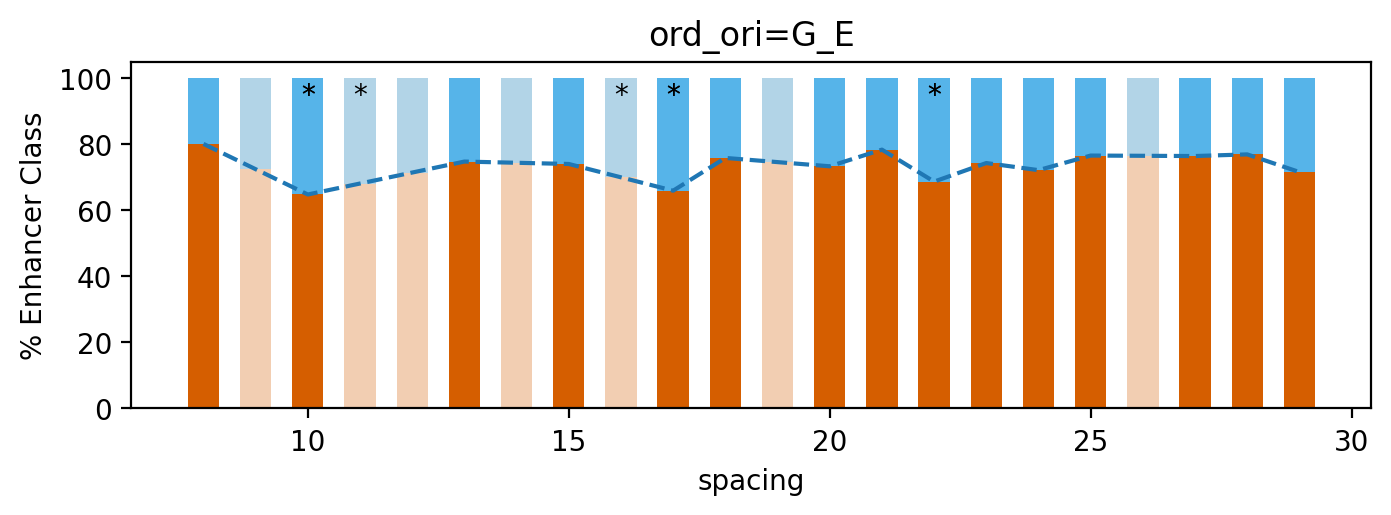

###############################################################
###############################################################
ANALYZING ord_ori=G_g

G_12_g
[25883, 26485] N = 26184.0
% s  =  0.104
% p  =  22.542
act =  2733
background % =  52139 431974 0.12069939394500595
pval =  1
2733 9390.885675348296 49406 134408.11432465172
OR = 0.7917332285463462

G_19_g
[26883, 8753] N = 17818.0
% s  =  0.116
% p  =  25.23
act =  2074
background % =  52139 431974 0.12069939394500595
pval =  1
2074 6146.53503813307 50065 137652.46496186694
OR = 0.9277440178563515

G_7_g
[25442] N = 25442.0

G_26_g
[2108, 8794] N = 5451.0
% s  =  0.108
% p  =  23.347
act =  588
background % =  52139 431974 0.12069939394500595
pval =  1
588 1930.5672771199675 51551 141868.43272288004
OR = 0.8381872726827369

G_11_g
[25883, 26485] N = 26184.0
% s  =  0.088
% p  =  18.972
act =  2314
background % =  52139 431974 0.12069939394500595
pval =  1
2314 9882.861002157804 49825 133916.1389978422
OR = 0.6293123858962324

G_

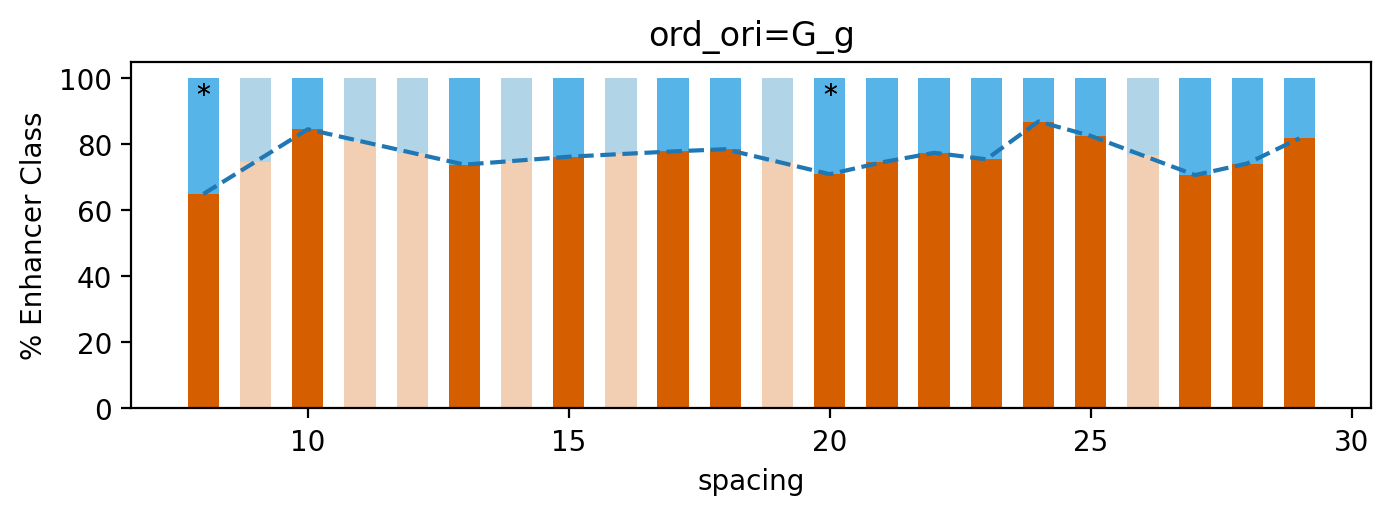

###############################################################
###############################################################
ANALYZING ord_ori=E_g

E_14_g
[52734, 51317] N = 52025.5
% s  =  0.111
% p  =  24.458
act =  5769
background % =  52139 431974 0.12069939394500595
pval =  1
5769 17818.343745455655 46370 125980.65625454434
OR = 0.8796298861521111

E_12_g
[51317, 52702] N = 52009.5
% s  =  0.12
% p  =  26.481
act =  6250
background % =  52139 431974 0.12069939394500595
pval =  1
6250 17351.795278342684 45889 126447.20472165731
OR = 0.9925130862146946

E_7_g
[52012] N = 52012.0

E_19_g
[56039, 15297] N = 35668.0
% s  =  0.113
% p  =  24.835
act =  4029
background % =  52139 431974 0.12069939394500595
pval =  1
4029 12193.949582635152 48110 131605.05041736484
OR = 0.9038369072607118

E_26_g
[8569, 15534] N = 12051.5
% s  =  0.1
% p  =  21.921
act =  1201
background % =  52139 431974 0.12069939394500595
pval =  1
1201 4277.778700463668 50938 139521.22129953632
OR = 0.7689942169287

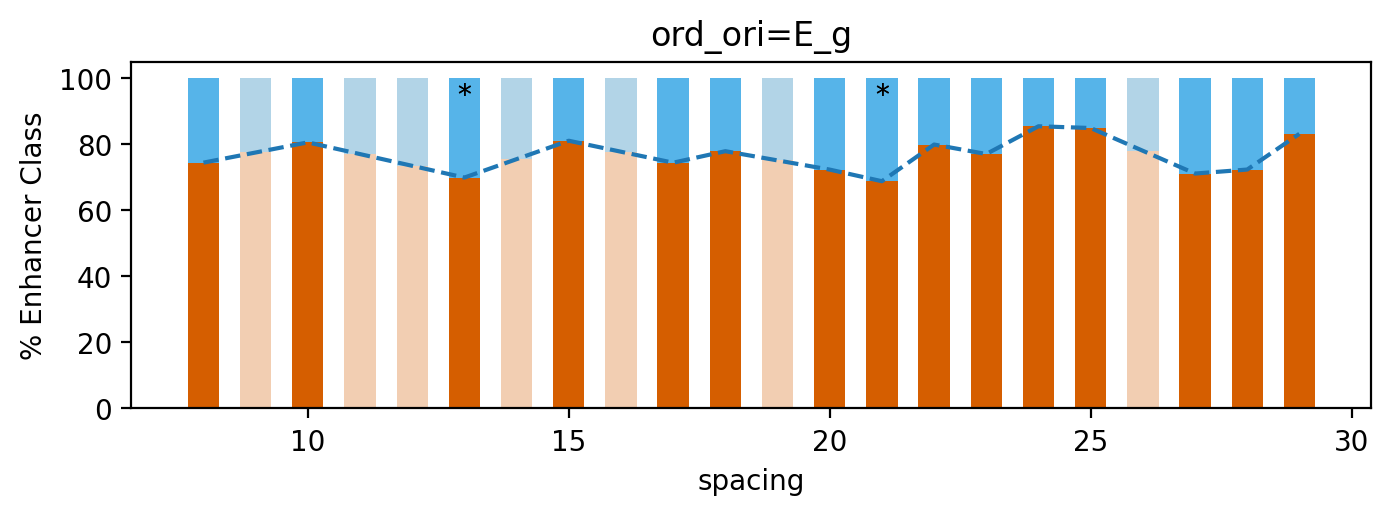

###############################################################


In [39]:
ordOriMotifsAnalyzed=set()
for i,(phraseKey,phraseLen,oddsRatio) in enumerate(zipdf(spcDF,['phrase-key','phrase-length','func-odds-ratio'])):
    # print(i,end=', ')

    if phraseKey not in MotifGraph: continue
    if '-spc' not in MotifGraph[phraseKey]: continue
    ordOriMotifSet=MotifGraph[phraseKey]['-spc']
    
    if phraseLen==3: continue
    
    for ordOriMotif in ordOriMotifSet:
        if (ordOriMotif in ordOriMotifsAnalyzed) or (jsgo.motif_revcomp_with_phrasetype(ordOriMotif) in ordOriMotifsAnalyzed):
            # print('###############################################################')
            # print('SKIPPPED',ordOriMotif)
            # print('###############################################################')
            continue
            
        else:
            
            print('###############################################################')
            print('ANALYZING',ordOriMotif)
            
            if phraseLen==2:
                get_missing_spacing_data_2mer(ordOriMotif,
                                               MotifGraph,
                                               spcMax=30,
                                               graphSpacingModel=True,
                                               graphEffectModel=False,
                                               savefigs=False,
                                               appendSpcDF=True)
                
            elif phraseLen==3:
                raise ValueError('we only do this for syntax feature of length 2')

            else:
                raise ValueError('incorrect num tfbs')
                
            ordOriMotifsAnalyzed.add(ordOriMotif)
            ordOriMotifsAnalyzed.add(jsgo.motif_revcomp_with_phrasetype(ordOriMotif))
            
            print('###############################################################')


# Output

In [41]:
spcDF=spcDF.set_index('phrase-key')
spcDF.head()

,phrase-length,func-odds-ratio,real-data,hyp-func-p-bonf,num-total-seqs,num-active-ens,obs-or-imputed
phrase-key,,,,,,,
ord_ori_spc=g_21_e_24_E,3.0,11.206427,"(63, 34, 7)",3.246130e-29,104.0,63.0,obs
ord_ori_spc=g_13_e_24_E,3.0,8.385350,"(108, 73, 21)",3.208155e-43,202.0,108.0,obs
ord_ori_spc=g_36_g_9_E,3.0,7.889255,"(162, 108, 42)",8.148688e-63,312.0,162.0,obs
ord_ori_spc=g_15_E_22_E,3.0,7.098879,"(107, 85, 25)",2.072536e-38,217.0,107.0,obs
ord_ori_spc=e_24_E_8_G,3.0,7.029848,"(105, 80, 29)",2.031084e-37,214.0,105.0,obs


In [44]:
spcDF.to_pickle('F05-Syntax-Features/6-real-and-imputed-motifs.pd.df.pickle')
spcDF.to_csv('F05-Syntax-Features/6-real-and-imputed-motifs.tsv',sep='\t')